<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/notebooks/kan_vs_mlp_sp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Часть 1. Генерация данных**

1.1. Генерация траекторий численным интегрированием: координата *x(t)*, скорость *v(t)* и ускорение *a(t)* при **разных начальных условиях** и **разных константах** *k*, *c* - жесткости пружины и сопротивления среды.

In [60]:
from scipy.integrate import solve_ivp
import numpy as np

def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []
m = 1.0  # масса маятника

for k in [2.0, 4.0, 6.0]: # цикл по жесткости и сопротивлению
    for c in [0.1, 0.5, 1.0]:

        for x0 in [1.0, 0.5, 2.0]: # цикл по начальным условиям
            for v0 in [0.0, 0.5, -0.5]:

                sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 20, 500))
                # запуск численного интегрирования от t[0,20], 500 значений

                x, v = sol.y # извлечение из результата (sol) массив из координат и скоростей
                a = -(k/m)*x - (c/m)*v # вычисление ускорения

                # сохрание точек (x, v, a)
                for i in range(len(x)):
                    all_data.append([x[i], v[i], k, c, a[i]])

1.2. Формирование датасета из полученных данных с применением нормализации, так как приведенность данных к единому масштабу критически важна при обучении MLP (при обучении KAN - полезно, но не обзательно).

In [61]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

all_data = np.array(all_data) # список -> массив NumPy

# разделение значений на х (вход) и у (выход)
x = all_data[:, :4]   # (x, v, k, c)
y = all_data[:, 4]    # a

# разбивание данных на train/test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


# НОРМАЛИЗАЦИЯ ДАННЫХ - приведение к нулевому среднему и единичному стандартному отклонению
scaler_x = StandardScaler() # масштабирование входов
x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

scaler_y = StandardScaler() # масштабирование выходов (опционально)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"Среднее x_train: {x_train_scaled.mean():.2f}")
print(f"Станд. откл. x_train: {x_train_scaled.std():.2f}")

# превращение данных в тензоры PyTorch, можно передавать MLP для обучения
x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1, 1)
x_test_t = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).reshape(-1, 1)

# Датасет для MLP
dataset_full = {
    'train_input': x_train_t,
    'train_label': y_train_t,
    'test_input': x_test_t,
    'test_label': y_test_t
}

# Датасет для KAN
n_sub = 2000 # уменьшение обучающей выборки, так как для KAN больше 2000 точек излишне
idx = np.random.choice(len(x_train_t), n_sub, replace=False)
dataset_small = {
    'train_input': x_train_t[idx],
    'train_label': y_train_t[idx],
    'test_input': x_test_t,
    'test_label': y_test_t
}

print(f"Размер train KAN : {dataset_small['train_input'].shape[0]} примеров")
print(f"Размер test  KAN : {dataset_small['test_input'].shape[0]} примеров")
print(f"Размер train MLP : {dataset_full['train_input'].shape[0]} примеров")
print(f"Размер test  MLP : {dataset_full['test_input'].shape[0]} примеров")

Среднее x_train: -0.00
Станд. откл. x_train: 1.00
Размер train KAN : 2000 примеров
Размер test  KAN : 8100 примеров
Размер train MLP : 32400 примеров
Размер test  MLP : 8100 примеров


# **Часть 2. Обучение KAN (без шума)**

2.1. Установка pykan, проверка наличия видеокарты


In [ ]:
!pip install git+https://github.com/KindXiaoming/pykan.git

from kan import KAN
from kan.utils import ex_round
import torch
torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']

2.2. Создание и обучение KAN с маленькой сеткой

In [ ]:
model_kan_small = KAN(width=[4, 2, 1], grid=3, k=3, seed=42, device=device)

model_kan_small(dataset_small['train_input']);
model_kan_small.plot()

In [ ]:
# 300-500 шагов обучения для данной архитектуры должно хватить для выхода на плато
steps = 10
train_losses_kan_small = []
test_losses_kan_small = []

# обучаем по одному шагу, сохраняя потери
for step in range(steps):
    result = model_kan_small.fit(dataset_small, opt="LBFGS", steps=30, lamb=0.0, lamb_entropy=0.0)

    train_losses_kan_small.append(result['train_loss'])
    test_losses_kan_small.append(result['test_loss'])

In [ ]:
model_kan_small.plot()

In [ ]:
# символическая регрессия
model_kan_small.auto_symbolic(lib=lib)
ex_round(model_kan_small.symbolic_formula()[0][0],4)

2.3. Создание и обучение KAN c большей сеткой

In [ ]:
model_kan = KAN(width=[4, 2, 1], grid=7, k=3, seed=42, device=device)

model_kan(dataset_small['train_input']);
model_kan.plot()

# 1000-1500 шагов обучения для данной архитектуры должно хватить для выхода на плато
steps = 10
train_losses_kan = []
test_losses_kan = []

# обучаем по одному шагу, сохраняя потери
for step in range(steps):
    result = model_kan.fit(dataset_small, opt="LBFGS", steps=100, lamb=0.0, lamb_entropy=0.0)

    train_losses_kan.append(result['train_loss'])
    test_losses_kan.append(result['test_loss'])

model_kan.plot()

# символическая регрессия
model_kan.auto_symbolic(lib=lib)
ex_round(model_kan.symbolic_formula()[0][0],4)

# **Часть 3. Обучение MLP (без шума)**

3.1. Создание MLP с 97 параметрами

In [62]:
import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self): # конструктор
        super().__init__()
        self.fc1 = nn.Linear(4, 16)   # 4 входа -> 16 нейронов
        self.fc2 = nn.Linear(16, 1)   # 16 -> 1 выход
        self.relu = nn.ReLU()

    def forward(self, x): # описывает как данные проходят через сеть
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_mlp = MLP() # MLP

criterion = nn.MSELoss() # функция потерь
optimizer = optim.Adam(model_mlp.parameters(), lr=0.01) # оптимизатор

3.2. Обучение MLP. 5000-8000 эпох для данной архитектуры должно хватить для выхода на плато.

In [64]:
epochs = 5000
train_losses_mlp = []
test_losses_mlp = []

# берем данные из датасета
x_train, y_train = dataset_full['train_input'], dataset_full['train_label']
x_test, y_test   = dataset_full['test_input'], dataset_full['test_label']

for epoch in range(epochs):
    model_mlp.train() # перевод в режим обучения
    optimizer.zero_grad() # обнуление градиентов

    # Прямой проход
    pred = model_mlp(x_train)
    loss = criterion(pred, y_train)

    # Обратный проход
    loss.backward()
    optimizer.step()

    model_mlp.eval() # перевод в режим оценки
    with torch.no_grad(): # отключение вычисления градиентов для тестов
        test_loss = criterion(model_mlp(x_test), y_test)

    # Вывод каждые 500 эпох
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs} | train_loss: {loss.item():.6f} | test_loss: {test_loss.item():.6f}")

        # сохранение значений среднеквадратичной ошибки
        train_losses_mlp.append(loss.item())
        test_losses_mlp.append(test_loss.item())

Epoch 500/5000 | train_loss: 0.001655 | test_loss: 0.001819
Epoch 1000/5000 | train_loss: 0.000470 | test_loss: 0.000504
Epoch 1500/5000 | train_loss: 0.000333 | test_loss: 0.000361
Epoch 2000/5000 | train_loss: 0.000213 | test_loss: 0.000242
Epoch 2500/5000 | train_loss: 0.000146 | test_loss: 0.000176
Epoch 3000/5000 | train_loss: 0.000119 | test_loss: 0.000144
Epoch 3500/5000 | train_loss: 0.000099 | test_loss: 0.000119
Epoch 4000/5000 | train_loss: 0.000459 | test_loss: 0.000563
Epoch 4500/5000 | train_loss: 0.000195 | test_loss: 0.000294
Epoch 5000/5000 | train_loss: 0.000043 | test_loss: 0.000057


3.3. Построение графика

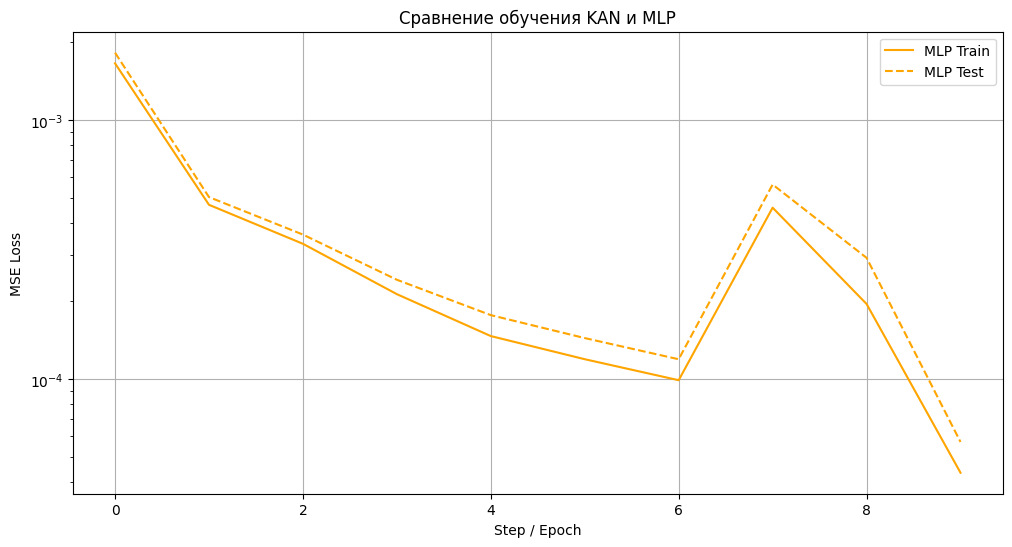

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Кривые для KAN
plt.plot(train_losses_kan_small, label='Small KAN Train', color='green', linestyle='-')
plt.plot(test_losses_kan_small,  label='Small KAN Test',  color='green', linestyle='--')

plt.plot(train_losses_kan, label='KAN Train', color='blue', linestyle='-')
plt.plot(test_losses_kan,  label='KAN Test',  color='blue', linestyle='--')

# Кривые для MLP
plt.plot(train_losses_mlp, label='MLP Train', color='orange', linestyle='-')
plt.plot(test_losses_mlp,  label='MLP Test',  color='orange', linestyle='--')

plt.xlabel('Step / Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.title('Сравнение обучения KAN и MLP')
plt.show()